In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import Hamiltonian as ham
import PauliStrings as pauli_strings
import scipy.sparse as sp
import numpy as np
from matplotlib import pyplot as plt
import Evolution as evol

In [33]:
def fidelity_pure(psi,phi):
    '''
    input values should be column vectors
    '''
    F=np.abs(psi.conj().T@phi)**2
    return F[0,0]

def random_state(n):
    psi = np.transpose(np.random.randn(2**n) + 1j*np.random.randn(2**n))
    return sp.csc_matrix(psi / np.linalg.norm(psi))

def singlet_state(num_pairs):
    """
    Returns:
        CSC sparse column vector representing
        tensor product of `num_pairs` singlets.
    """

    # |Ψ⁻> = (|01> - |10>) / sqrt(2)
    singlet = (1 / np.sqrt(2)) * sp.csc_matrix(
        [[0],
         [1],
         [-1],
         [0]],
        dtype=complex
    )

    psi = singlet

    for _ in range(num_pairs - 1):
        psi = sp.kron(psi, singlet, format='csc')

    return psi

In [9]:
def QITE_ACQ_Heisenberg_evol(J,n_qubits,D,psi_0):
    #trotter params
    H,H_trot=ham.Heisenberg(J,n_qubits)
    print('Computing Eigs')
    EH,VH = np.linalg.eigh(H.todense())
    psigs=VH[:,0]
    E_gs=EH[0]

    #evolution parameters
    dt=0.1
    N=100
    tmax=dt*N
    t=0 + np.arange(0, N+1) *dt


    #QITE and ITE evolution
    print("Computing QITE")
    NQ=20
    EQ,psi_QITE,aQITE = evol.QITE(n_qubits,H,H_trot,D,psi_0,NQ,dt,vervose=False,OBC=True)
    print("ACQ QITE")
    dt_ACQ=0.05
    E_ACQ,psi_ACQ,indx,tACQ,aACQ = evol.ACQ(n_qubits,H,H_trot,D,psi_0,N,dt_ACQ,OBC=True)

    #Fidelities
    F_ACQ=np.zeros(N+1)
    for i in range(N+1):
        F_ACQ[i]=fidelity_pure(psigs,psi_ACQ[:,i].todense())

    #Fidelities
    F_Q=np.zeros(len(EQ))
    for i in range(len(EQ)):
        F_Q[i]=fidelity_pure(psigs,psi_QITE[:,i].todense())

    return EQ, F_Q, E_ACQ[indx], F_ACQ[indx]

In [28]:
def QITE_ACQ_Heisenberg(J,n_qubits,D,psi_0):
    #trotter params
    H,H_trot=ham.Heisenberg(J,n_qubits)
    print('Computing Eigs')
    EH,VH = np.linalg.eigh(H.todense())
    psigs=VH[:,0]
    E_gs=EH[0]

    #evolution parameters
    dt=0.1
    N=100
    tmax=dt*N
    t=0 + np.arange(0, N+1) *dt

    #QITE and ITE evolution
    print("Computing QITE")
    NQ=20
    EQ,psi_QITE,aQITE = evol.QITE(n_qubits,H,H_trot,D,psi_0,NQ,dt,vervose=False,OBC=True)
    print("ACQ QITE")
    dt_ACQ=0.05
    E_ACQ,psi_ACQ,indx,tACQ,aACQ = evol.ACQ(n_qubits,H,H_trot,D,psi_0,N,dt_ACQ,OBC=True)

    #Fidelities
    F_ACQ=np.zeros(N+1)
    for i in range(N+1):
        F_ACQ[i]=fidelity_pure(psigs,psi_ACQ[:,i].todense())

    #Fidelities
    F_Q=np.zeros(len(EQ))
    for i in range(len(EQ)):
        F_Q[i]=fidelity_pure(psigs,psi_QITE[:,i].todense())

    return EQ[-1], F_Q[-1], E_ACQ[-1], F_ACQ[indx[-1]]

## Plots Heisenberg model

In [47]:
J=1
N=range(6,11,2)
 
D=4 #at D=2 truncation is too severe to see any convergence to the GS
FQ4=np.zeros(len(N))
EQ4=np.zeros(len(N))
FACQ4=np.zeros(len(N))
EACQ4=np.zeros(len(N))
for i in range(len(N)):
    psi_0=singlet_state(N[i]//2)
    EQ4[i], FQ4[i], EACQ4[i], FACQ4[i] = QITE_ACQ_Heisenberg(J,N[i],D,psi_0)

Heisenberg model with OBC and Hamiltonian pieces of locality T=2
Succesfull Troterization
The Trotterization consists of 5 terms with the starting qubit of each piece at [0, 1, 2, 3, 4]
Computing Eigs
Computing QITE
Energy doubly increased at step 4
ACQ QITE
Computing U at step 0
Computing U at step 4
Computing U at step 6
Energy doubly increased, stopping criteria activated at step 7
Heisenberg model with OBC and Hamiltonian pieces of locality T=2
Succesfull Troterization
The Trotterization consists of 7 terms with the starting qubit of each piece at [0, 1, 2, 3, 4, 5, 6]
Computing Eigs
Computing QITE
Energy doubly increased at step 5
ACQ QITE
Computing U at step 0
Computing U at step 3
Computing U at step 7
Computing U at step 9
Energy doubly increased, stopping criteria activated at step 10
Heisenberg model with OBC and Hamiltonian pieces of locality T=2
Succesfull Troterization
The Trotterization consists of 9 terms with the starting qubit of each piece at [0, 1, 2, 3, 4, 5, 6, 7, 

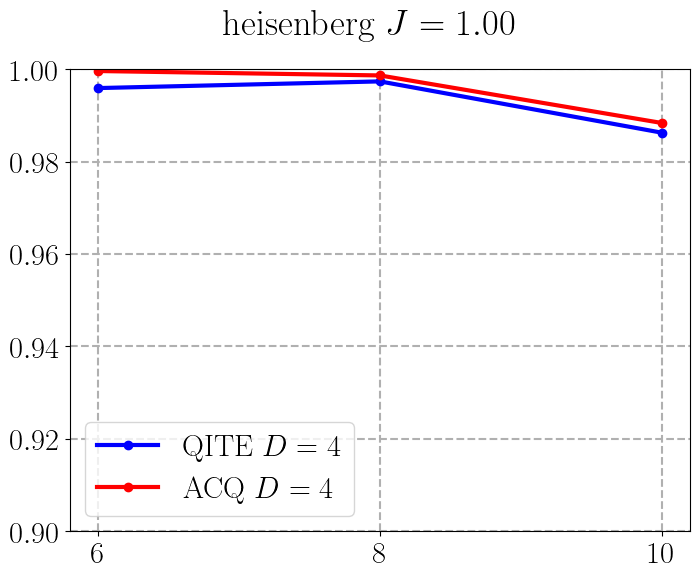

In [49]:
plt.figure(figsize=(8, 6))
plt.rcParams.update({
    "text.usetex": True,
})
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 22}

plt.rc('font', **font)
plt.suptitle("heisenberg $J=%.2f$"%(J))


plt.plot(N,FQ4,'-bo',linewidth=3,label='QITE $D=%d$'%4)
plt.plot(N,FACQ4,'-ro',linewidth=3,label='ACQ $D=%d$'%4)
plt.legend()
plt.xticks(N)
plt.ylim(0.9,1)
plt.grid(linestyle = '--', linewidth = 1.5)
plt.savefig("Heisenberg_Singlet.png")

# Example During Evolution

In [50]:
J=1
n_qubits=8
D=4
psi_0=singlet_state(n_qubits//2)
EQ,F_Q,E_ACQ,F_ACQ=QITE_ACQ_Heisenberg_evol(J,n_qubits,D,psi_0)

Heisenberg model with OBC and Hamiltonian pieces of locality T=2
Succesfull Troterization
The Trotterization consists of 7 terms with the starting qubit of each piece at [0, 1, 2, 3, 4, 5, 6]
Computing Eigs
Computing QITE
Energy doubly increased at step 5
ACQ QITE
Computing U at step 0
Computing U at step 3
Computing U at step 7
Computing U at step 9
Energy doubly increased, stopping criteria activated at step 10


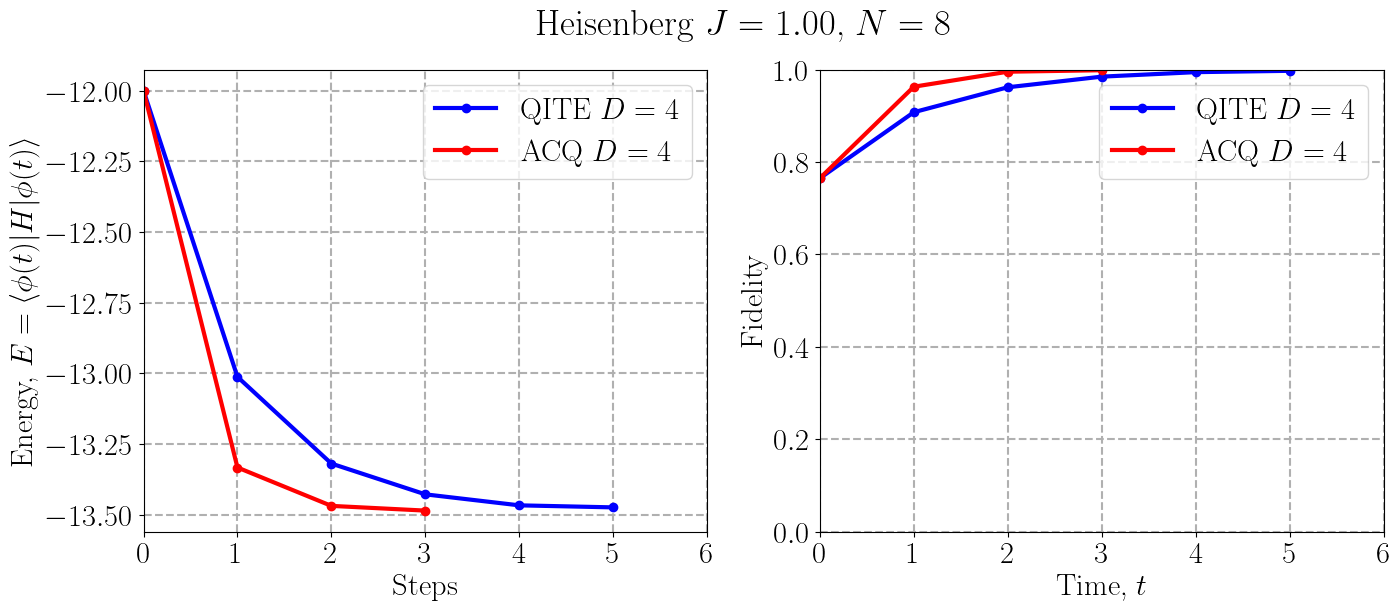

In [51]:
plt.figure(figsize=(16, 6))
plt.rcParams.update({
    "text.usetex": True,
})
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 22}

plt.rc('font', **font)
plt.suptitle("Heisenberg $J=%.2f$, $N=%d$"%(J,n_qubits))

plt.subplot(1,2,1)
plt.plot(EQ,'-bo',linewidth=3,label='QITE $D=%d$'%D)
plt.plot(E_ACQ,'-ro',linewidth=3,label='ACQ $D=%d$'%D)
plt.xlabel("Steps")
plt.ylabel("Energy, $E=\\langle \\phi(t)|H|\\phi(t)\\rangle$")
plt.xlim(0,max(len(E_ACQ),len(EQ)))
plt.legend()
plt.grid(linestyle = '--', linewidth = 1.5)

plt.subplot(1,2,2)
plt.plot(F_Q,'-bo',linewidth=3,label='QITE  $D=%d$'%D)
plt.plot(F_ACQ,'-ro',linewidth=3,label='ACQ  $D=%d$'%D)
plt.xlabel("Time, $t$")
plt.ylabel("Fidelity")
plt.xlim(0,max(len(E_ACQ),len(EQ)))
plt.ylim(0,1)
plt.legend()
plt.grid(linestyle = '--', linewidth = 1.5)
#plt.savefig("adaptive_QITE_N12D4.png")